In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from utils import tx_rx_system

## Anàlisi de l'Emisor

En aquesta etapa del projecte, ens centrem en el comportament del senyal enviat pel nostre LED driver. L'objectiu és validar que el circuit respon correctament a la freqüència de treball.

### 1. Generació del Senyal de Pols (1 kHz)

Per començar l'anàlisi, simulem la transmissió d'un senyal quadrat. Aquest senyal representa les dades digitals que volem transmetre.
Paràmetres de la Simulació:
- Freqüència: $1\text{ kHz}$ (període de $1\text{ ms}$).
- Amplitud: $3.3\text{ V}$ (nivell lògic estàndard).
- Cicle de treball (Duty Cycle): $50\%$.

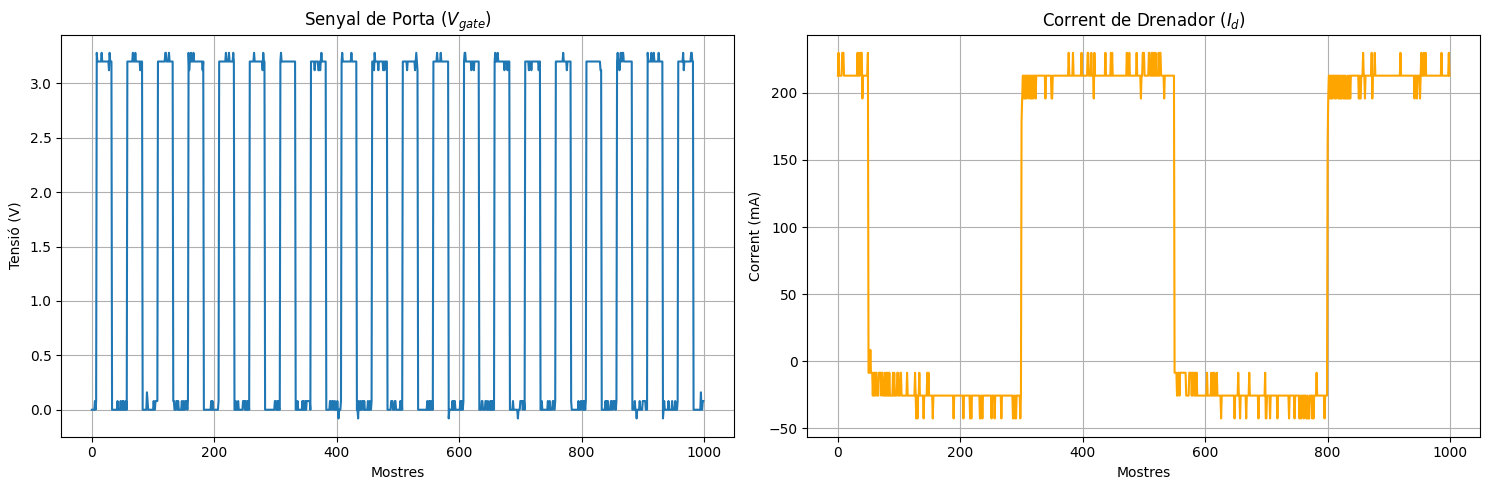

In [ ]:
tx_rx_system.convertir_senyal_osciloscopi("fitxers/1kHz_V_gate.csv", "fitxers/1kHz_V_gate_neta.csv", channels=1)
tx_rx_system.convertir_senyal_osciloscopi("fitxers/1kHz_Id.csv", "fitxers/1kHz_Id_neta.csv", channels=1)

signal_gate = np.loadtxt("fitxers/1kHz_V_gate_neta.csv", delimiter=',')
v_mesurada = np.loadtxt("fitxers/1kHz_Id_neta.csv", delimiter=',')

resistencia = 4.7  # Ohms
signal_Id = ((5 - v_mesurada) / resistencia) * 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(signal_gate[:1000])
ax1.set_title("Senyal de Porta ($V_{gate}$)")
ax1.set_xlabel("Mostres")
ax1.set_ylabel("Tensió (V)")
ax1.grid(True)

ax2.plot(signal_Id[:1000], color='orange')
ax2.set_title("Corrent de Drenador ($I_d$)")
ax2.set_xlabel("Mostres")
ax2.set_ylabel("Corrent (mA)")
ax2.grid(True)
plt.tight_layout()
plt.show()

#### Interpretació del resultat

### 2. Generació del Senyal de Pols (1 MHz)

En aquesta secció simulem la transmissió d'un senyal quadrat al sistema.

- Freqüència: 1 MHz.
- Amplitud: 3.3V.
- Objectiu: Demostrar que a aquesta freqüència, el voltatge $V_{gate}$ no té prou temps per carregar-se i assolir pràcticament els 3.3V.


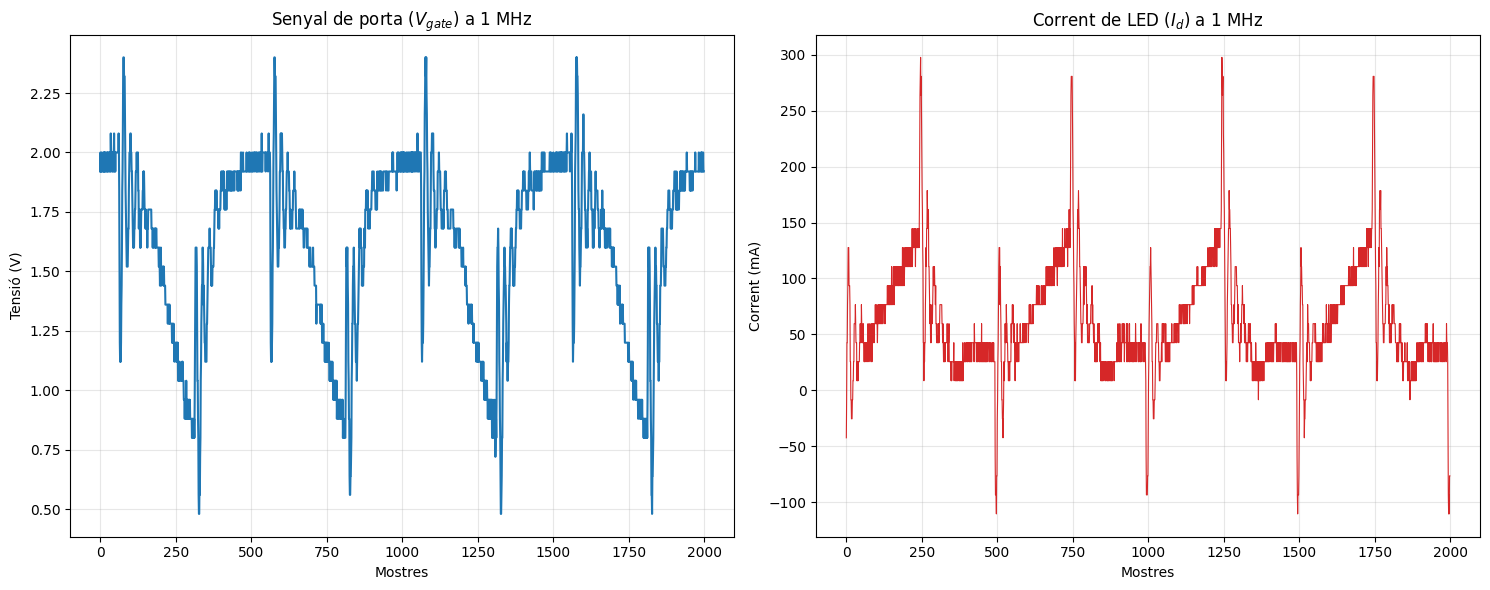

In [ ]:
tx_rx_system.convertir_senyal_osciloscopi(
    senyal_csv="fitxers/1MHz_V_gate.csv",
    senyal_neta_csv="fitxers/1MHz_V_gate_neta.csv",
    channels=1
)
tx_rx_system.convertir_senyal_osciloscopi(
    senyal_csv="fitxers/1MHz_Id.csv",
    senyal_neta_csv="fitxers/1MHz_Id_neta.csv",
    channels=1
)

signal_gate = np.loadtxt("fitxers/1MHz_V_gate_neta.csv", delimiter=',')
v_mesurada = np.loadtxt("fitxers/1MHz_Id_neta.csv", delimiter=',')

signal_Id = ((5 - v_mesurada) / resistencia) * 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(signal_gate[:2000], color='tab:blue')
ax1.set_title("Senyal de porta ($V_{gate}$) a 1 MHz")
ax1.set_xlabel("Mostres")
ax1.set_ylabel("Tensió (V)")
ax1.grid(True, alpha=0.3)
ax2.plot(signal_Id[:2000], color='tab:red', linewidth=0.8)
ax2.set_title("Corrent de LED ($I_d$) a 1 MHz")
ax2.set_xlabel("Mostres")
ax2.set_ylabel("Corrent (mA)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretació del resultat

### 3. Sweep de freqüència (de 1 kHz a 7.5 MHz) amb senyal de pols quadrat

En aquest apartat es realitza un sweep de freqüència, és a dir, una variació progressiva de la freqüència del senyal d’entrada des de 1 kHz fins a 7.5 MHz, mantenint la resta de paràmetres constants (amplitud i forma del senyal).

#### Objectiu:

L’objectiu principal és analitzar el comportament dinàmic del sistema davant diferents velocitats de commutació, i determinar fins a quina freqüència el sistema és capaç de respondre correctament.

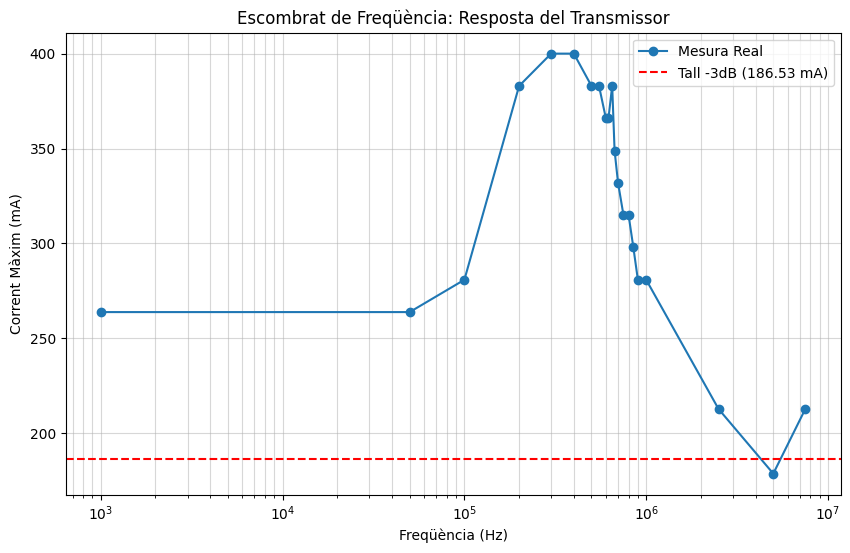

In [ ]:
freqs = [
    1000, 50000, 100000, 200000, 300000, 400000, 500000, 
    550000, 600000, 620000, 650000, 670000, 700000, 750000, 800000, 
    850000, 900000, 1000000, 2500000, 5000000, 7500000
]
senyals = ["a","b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u"]


max_currents = []
for senyal in senyals:
    tx_rx_system.convertir_senyal_osciloscopi(
        senyal_csv=f"fitxers/BW/{senyal}.csv",
        senyal_neta_csv=f"fitxers/BW/{senyal}_neta.csv",
        channels=1
    )
    v_mesurada = np.loadtxt(f"fitxers/BW/{senyal}_neta.csv", delimiter=',')
    signal_Id = ((5 - v_mesurada) / resistencia) * 1000
    max_currents.append(np.max(signal_Id))


i_base = max_currents[0]
i_cutoff = i_base * 0.707 

plt.figure(figsize=(10, 6))
plt.semilogx(freqs, max_currents, 'o-', label='Mesura Real')
plt.axhline(y=i_cutoff, color='r', linestyle='--', label=f'Tall -3dB ({i_cutoff:.2f} mA)')
plt.title("Escombrat de Freqüència: Resposta del Transmissor")
plt.xlabel("Freqüència (Hz)")
plt.ylabel("Corrent Màxim (mA)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

Després del primer sweep de freqüència, s’observa que els resultats obtinguts no són del tot correctes ni representatius del comportament real del sistema.

Això es deu al fet que apareixen pics d’overshoot en el senyal de sortida, tal com es pot veure en els gràfics següents:

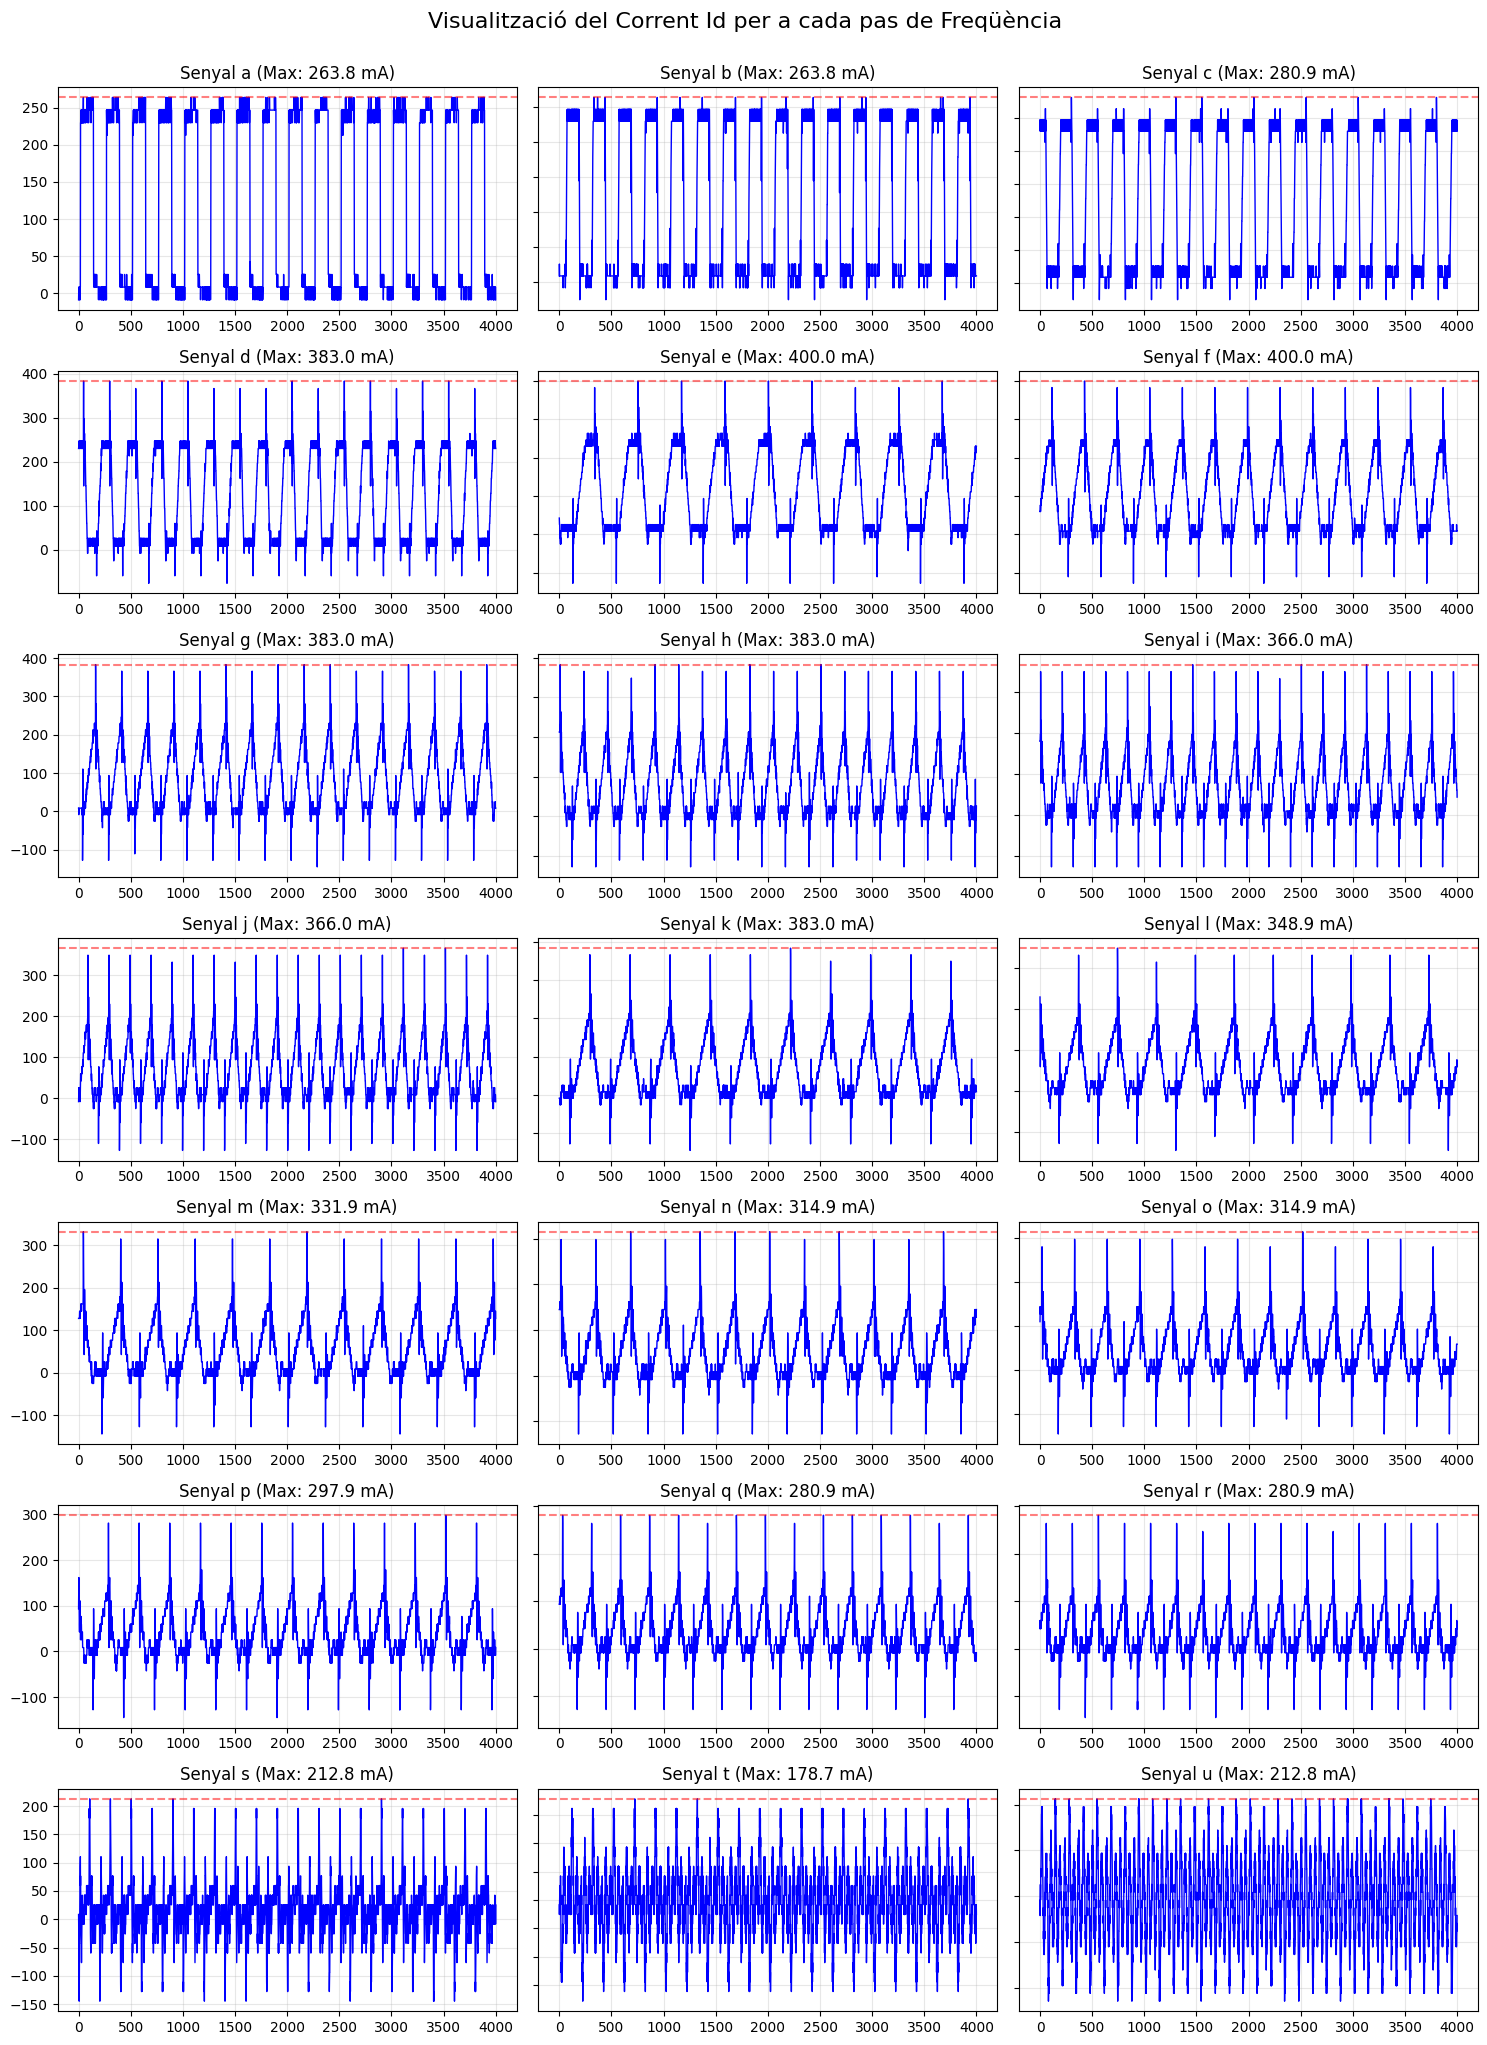

In [ ]:

fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))
axes = axes.flatten() 

for i, senyal in enumerate(senyals):    
    v_mesurada = np.loadtxt(f"fitxers/BW/{senyal}_neta.csv", delimiter=',')
    signal_Id = ((5 - v_mesurada) / resistencia) * 1000
    axes[i].plot(signal_Id, color='blue', linewidth=1)
    valor_max = np.max(signal_Id)
    axes[i].axhline(y=valor_max, color='red', linestyle='--', alpha=0.5)    
    axes[i].set_title(f"Senyal {senyal} (Max: {valor_max:.1f} mA)")
    axes[i].grid(True, alpha=0.3)
    if i % 3 != 0: axes[i].set_yticklabels([]) 

plt.tight_layout()
plt.suptitle("Visualització del Corrent Id per a cada pas de Freqüència", fontsize=16, y=1.02)
plt.show()

És per aquest motiu que, per tal d’obtenir una mesura més representativa del comportament real del sistema, s’opta per utilitzar percentils en lloc del valor màxim directe.

Concretament, s’utilitza el percentil 90 (P90) del corrent $I_d$ per a cada senyal. Aquest criteri permet ignorar els pics puntuals d’overshoot i quedar-se amb un valor que reflecteix millor el règim quasi estacionari del sistema.

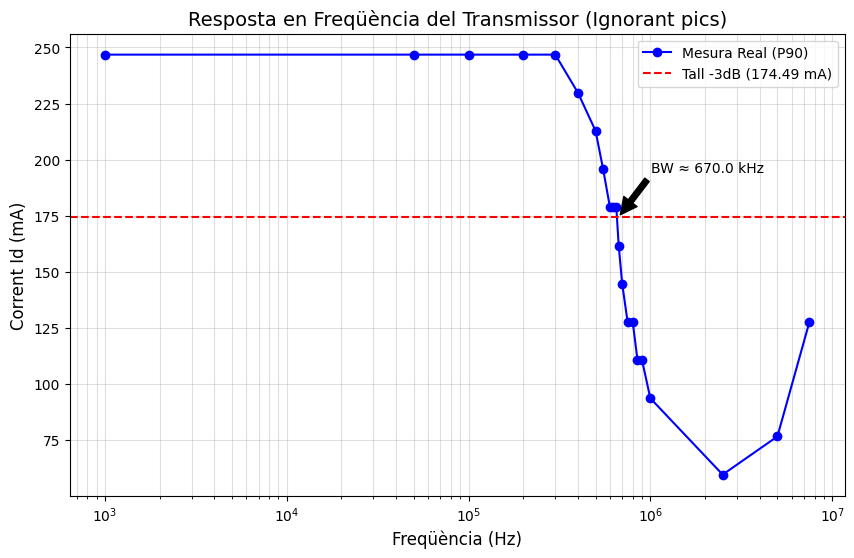

In [ ]:
max_currents = []
for senyal in senyals:
    v_mesurada = np.loadtxt(f"fitxers/BW/{senyal}_neta.csv", delimiter=',')
    signal_Id = ((5 - v_mesurada) / resistencia) * 1000
    valor_estable = np.percentile(signal_Id, 90)
    max_currents.append(valor_estable)

i_base = max_currents[0]  
i_cutoff = i_base * 0.707 

plt.figure(figsize=(10, 6))
plt.semilogx(freqs, max_currents, 'o-', color='blue', label='Mesura Real (P90)')
plt.axhline(y=i_cutoff, color='red', linestyle='--', label=f'Tall -3dB ({i_cutoff:.2f} mA)')
plt.title("Resposta en Freqüència del Transmissor (Ignorant pics)", fontsize=14)
plt.xlabel("Freqüència (Hz)", fontsize=12)
plt.ylabel("Corrent Id (mA)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend()

idx_cutoff = np.where(np.array(max_currents) < i_cutoff)[0]
if len(idx_cutoff) > 0:
    f_tall = freqs[idx_cutoff[0]]
    plt.annotate(f'BW ≈ {f_tall/1000} kHz', xy=(f_tall, i_cutoff), xytext=(f_tall*1.5, i_cutoff+20),
                 arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

## Anàlisi del Sistema Complet (TX I RX amb sensor MAX3012)
